# Machine Learning CA1 – Student Outcome Classification

---

| | |
|---|---|
| **Programme** | BSc (Hons) in Computing – Artificial Intelligence |
| **Module** | Machine Learning for AI |
| **Lecturer** | David McQuaid |
| **Assignment** | ML_CA1_V7 |
| **Submission Deadline** | 19/04/2026 at 11:59 pm |

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis)
3. [Data Preparation](#3-data-preparation)
4. [Classification Algorithms](#4-classification-algorithms)
5. [Final Classification and Accuracy Analysis](#5-final-classification)
6. [Conclusions](#6-conclusions)
7. [References](#7-references)


---
## 1. Introduction

This notebook covers the full ML pipeline for the CCT College Dublin Machine Learning CA1 assignment. The dataset (`student_dataV3.csv`) has demographic, socio-economic, and academic data for students at a Portuguese higher education institution. The goal is to classify each student as **Dropout**, **Enrolled**, or **Graduate** by the end of their normal course duration.

The work is split into four main parts:

- **Section 2** — EDA: getting to know the data, spotting distributions, relationships, and any quality issues (spoiler: there are a few).
- **Section 3** — Data Preparation: cleaning up the mess found in EDA and getting everything ready for modelling.
- **Section 4** — Classification Algorithms: building and tuning at least two classifiers, comparing results.
- **Section 5** — Final Classification: running the best model on the test set and analysing how well it generalises.

The dataset was originally published by Realinho et al. (2022) and has been widely used in educational data mining research.


---
## 2. Exploratory Data Analysis

### 2.1 Loading Libraries and the Dataset

Before doing anything else, let's load the data and take a look at what we're working with. We'll load it raw — no preprocessing yet — so we can see any data quality issues as they actually are.


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, f1_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Load raw data (keep as-is to expose dirty values)
df_raw = pd.read_csv('student_dataV3.csv')

# Normalise Target column: fix case/abbreviation inconsistencies
target_map = {
    'Grad': 'Graduate', 'graduate': 'Graduate',
    'Drop': 'Dropout',  'dropout': 'Dropout',
    'enrolled': 'Enrolled'
}
df_raw['Target'] = df_raw['Target'].replace(target_map)

print(f"Dataset shape: {df_raw.shape}")
print(f"Target classes after normalisation: {sorted(df_raw['Target'].unique())}")
df_raw.head()


Dataset shape: (4424, 37)
Target classes after normalisation: ['Dropout', 'Enrolled', 'Graduate']


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,6.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 2.2 Dataset Overview and Data Types


In [4]:
print("=== Data Types ===")
print(df_raw.dtypes)


=== Data Types ===
Marital status                                     object
Application mode                                    int64
Application order                                   int64
Course                                            float64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                            float64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                          object
Educational special needs                           int64
Debtor                                            float64
Tuition fees up to date                            ob

### 2.3 Dirty Data and Missing Value Detection

One of the first things worth checking is whether the data is actually clean. In this case, it's not — and the issues aren't all in the standard `NaN` format either.


In [5]:
# Identify all non-numeric values in columns that should be numeric
dirty_summary = {}
for col in df_raw.columns:
    if col == 'Target':
        continue
    series = df_raw[col]
    non_num_mask = pd.to_numeric(series, errors='coerce').isna()
    non_num_vals = series[non_num_mask]
    if len(non_num_vals) > 0:
        dirty_summary[col] = {
            'Count': len(non_num_vals),
            'Values Found': str(non_num_vals.unique().tolist())
        }

dirty_df = pd.DataFrame(dirty_summary).T
print(f"Columns with dirty/missing values: {len(dirty_df)}")
print()
print(dirty_df.to_string())


Columns with dirty/missing values: 13

                                    Count Values Found
Marital status                          1        ['?']
Course                                  1        [nan]
Father's qualification                  1        [nan]
Admission grade                         1        [nan]
Displaced                               1        ['?']
Debtor                                  1        [nan]
Tuition fees up to date                 2   [nan, '?']
Age at enrollment                       1  ['UnKnown']
International                           1        [nan]
Curricular units 1st sem (credited)     1       ['Na']
Curricular units 1st sem (grade)        1        [nan]
Curricular units 2nd sem (enrolled)     1        [nan]
Curricular units 2nd sem (grade)        1        [nan]


**EDA Finding 2.3 — Dirty Data:** The dataset has some data quality issues that aren't immediately obvious from the column types:

- **`'?'`** shows up in `Marital status`, `Displaced`, and `Tuition fees up to date` — probably representing unknown or refused answers.
- **`'UnKnown'`** appears in `Age at enrollment` — someone clearly wasn't consistent with their naming.
- **`'Na'`** in `Curricular units 1st sem (credited)` — a string version of a missing value.
- **Standard `NaN`** values are scattered across several other columns.
- **Target column inconsistencies**: The `Target` column also has variant spellings like `'Grad'`, `'graduate'`, `'Drop'`, and `'dropout'` — these all need to be normalised to the canonical values before any analysis.

These dirty values cause pandas to read entire columns as strings, which breaks any numerical analysis. This is exactly the kind of thing we need to fix in the data preparation phase.


### 2.4 Target Variable Distribution

Before building any model, it's worth checking how balanced the target classes are. Imbalanced classes can lead to models that just predict the majority class and still look decent on paper.


          Count  Percentage (%)
Target                         
Graduate   2209           49.93
Dropout    1421           32.12
Enrolled    794           17.95


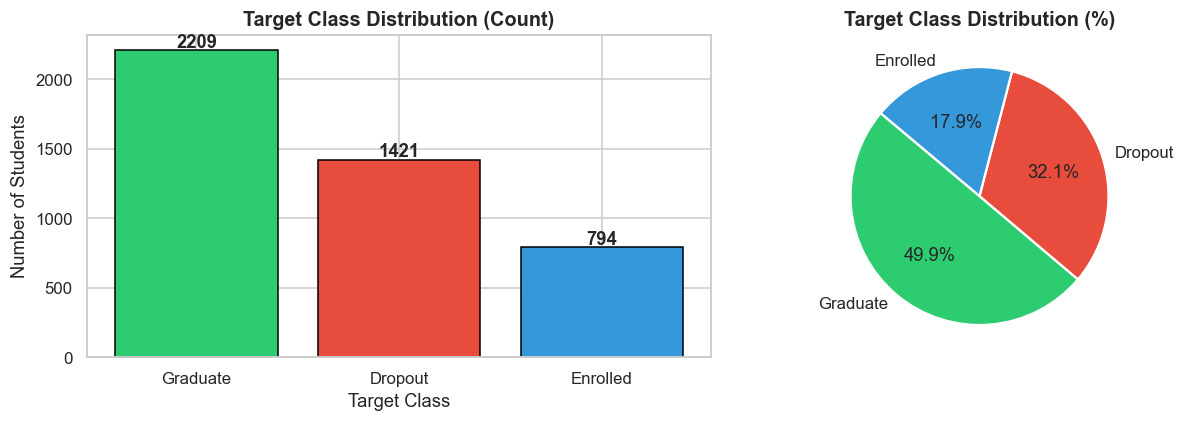

Figure saved.


In [6]:
target_counts = df_raw['Target'].value_counts()
target_pct = df_raw['Target'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_pct.round(2)
})
print(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette_target = {'Dropout': '#e74c3c', 'Enrolled': '#3498db', 'Graduate': '#2ecc71'}
colors = [palette_target[k] for k in target_counts.index]

axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Target Class')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Target Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_target_distribution.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.4:** The dataset is moderately imbalanced — *Graduate* is the majority class (~50%), followed by *Dropout* (~32%), with *Enrolled* being the smallest group (~18%). This matters because a naive classifier could just predict "Graduate" for everyone and still get ~50% accuracy without learning anything useful. We'll use stratified splitting and class-weight balancing to handle this.


### 2.5 Descriptive Statistics

Let's get a quick numerical summary of the continuous features. We'll temporarily coerce everything to numeric to make this work.


In [7]:
# Coerce all feature columns to numeric for descriptive stats
df_num_preview = df_raw.copy()
for col in df_num_preview.columns:
    if col != 'Target':
        df_num_preview[col] = pd.to_numeric(df_num_preview[col], errors='coerce')

df_num_preview.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Marital status,4423.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application mode,4424.0,18.67,17.48,1.00,1.00,17.00,39.00,57.00
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Course,4423.0,8856.46,2063.76,33.00,9085.00,9238.00,9556.00,9991.00
Daytime/evening attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification,4424.0,4.58,10.22,1.00,1.00,1.00,1.00,43.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Nacionality,4424.0,1.87,6.91,1.00,1.00,1.00,1.00,109.00
Mother's qualification,4424.0,19.56,15.60,1.00,2.00,19.00,37.00,44.00
Father's qualification,4423.0,22.27,15.34,1.00,3.00,19.00,37.00,44.00


### 2.6 Distribution of Continuous Features

Let's look at the distributions of the key numerical features to spot any skewness, outliers, or unusual patterns.


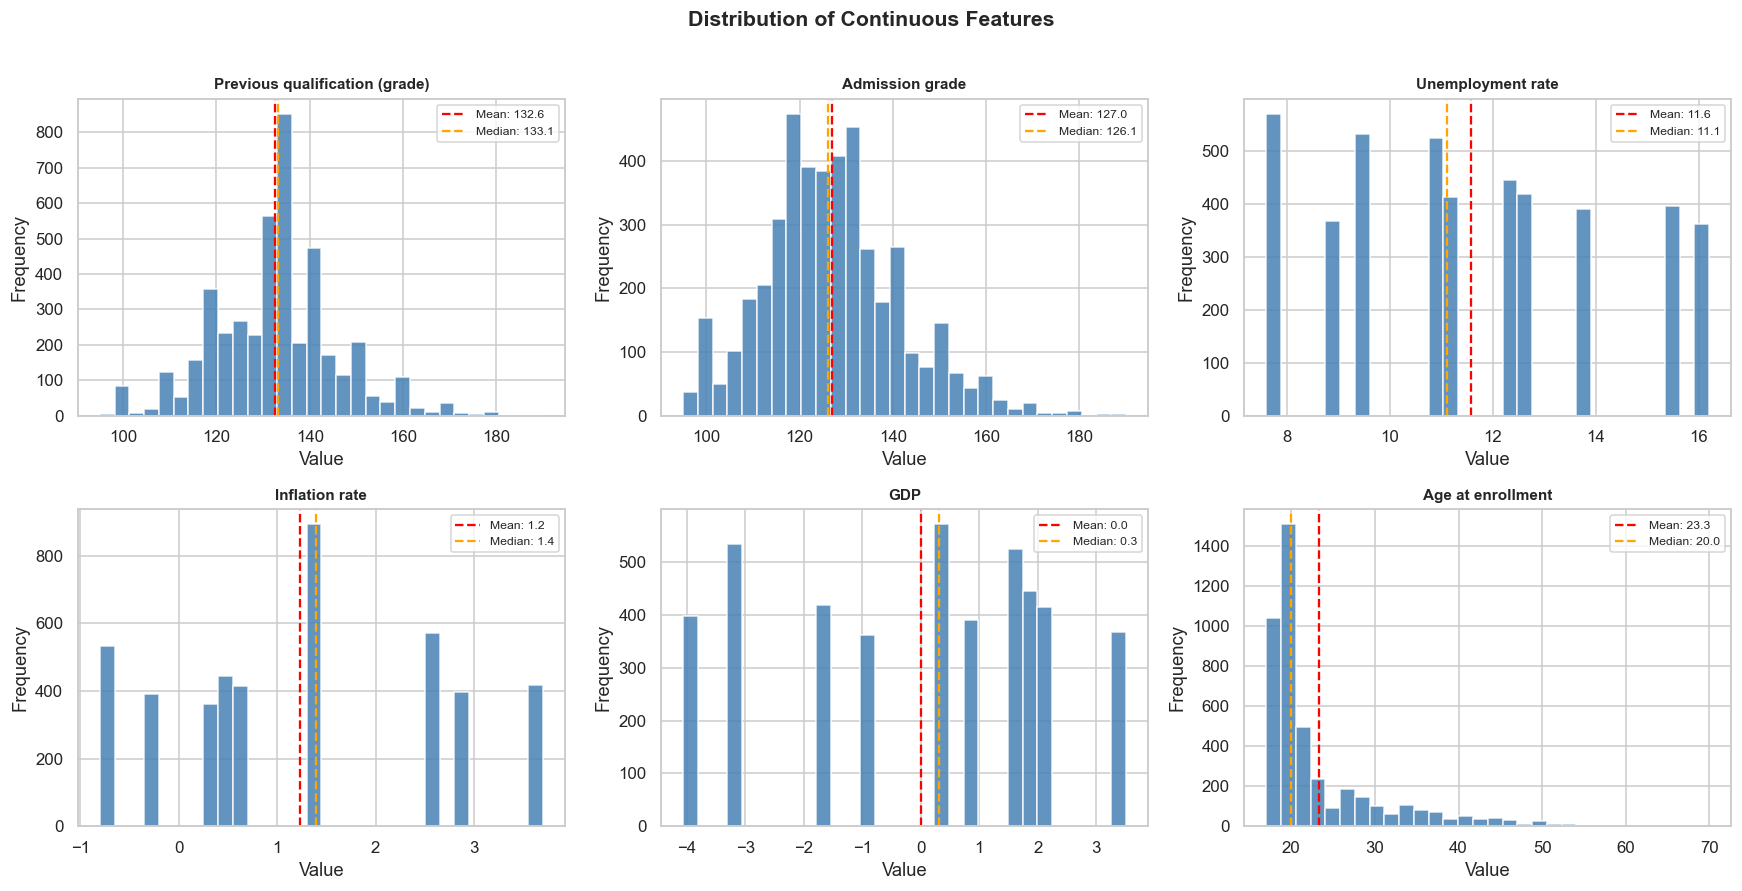

Figure saved.


In [8]:
continuous_cols = ['Previous qualification (grade)', 'Admission grade',
                   'Unemployment rate', 'Inflation rate', 'GDP',
                   'Age at enrollment']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    series = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    axes[i].hist(series, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(series.mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean: {series.mean():.1f}')
    axes[i].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5,
                    label=f'Median: {series.median():.1f}')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Continuous Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_continuous_distributions.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.6:** `Age at enrollment` is right-skewed — most students enroll young (17–25), but there's a long tail of mature students. `Admission grade` and `Previous qualification (grade)` look roughly bell-shaped. The macroeconomic features (GDP, unemployment, inflation) show limited variability, which suggests they won't be great individual predictors.


### 2.7 Continuous Features by Target Class

Boxplots are great for seeing at a glance how continuous features differ between the three outcome groups.


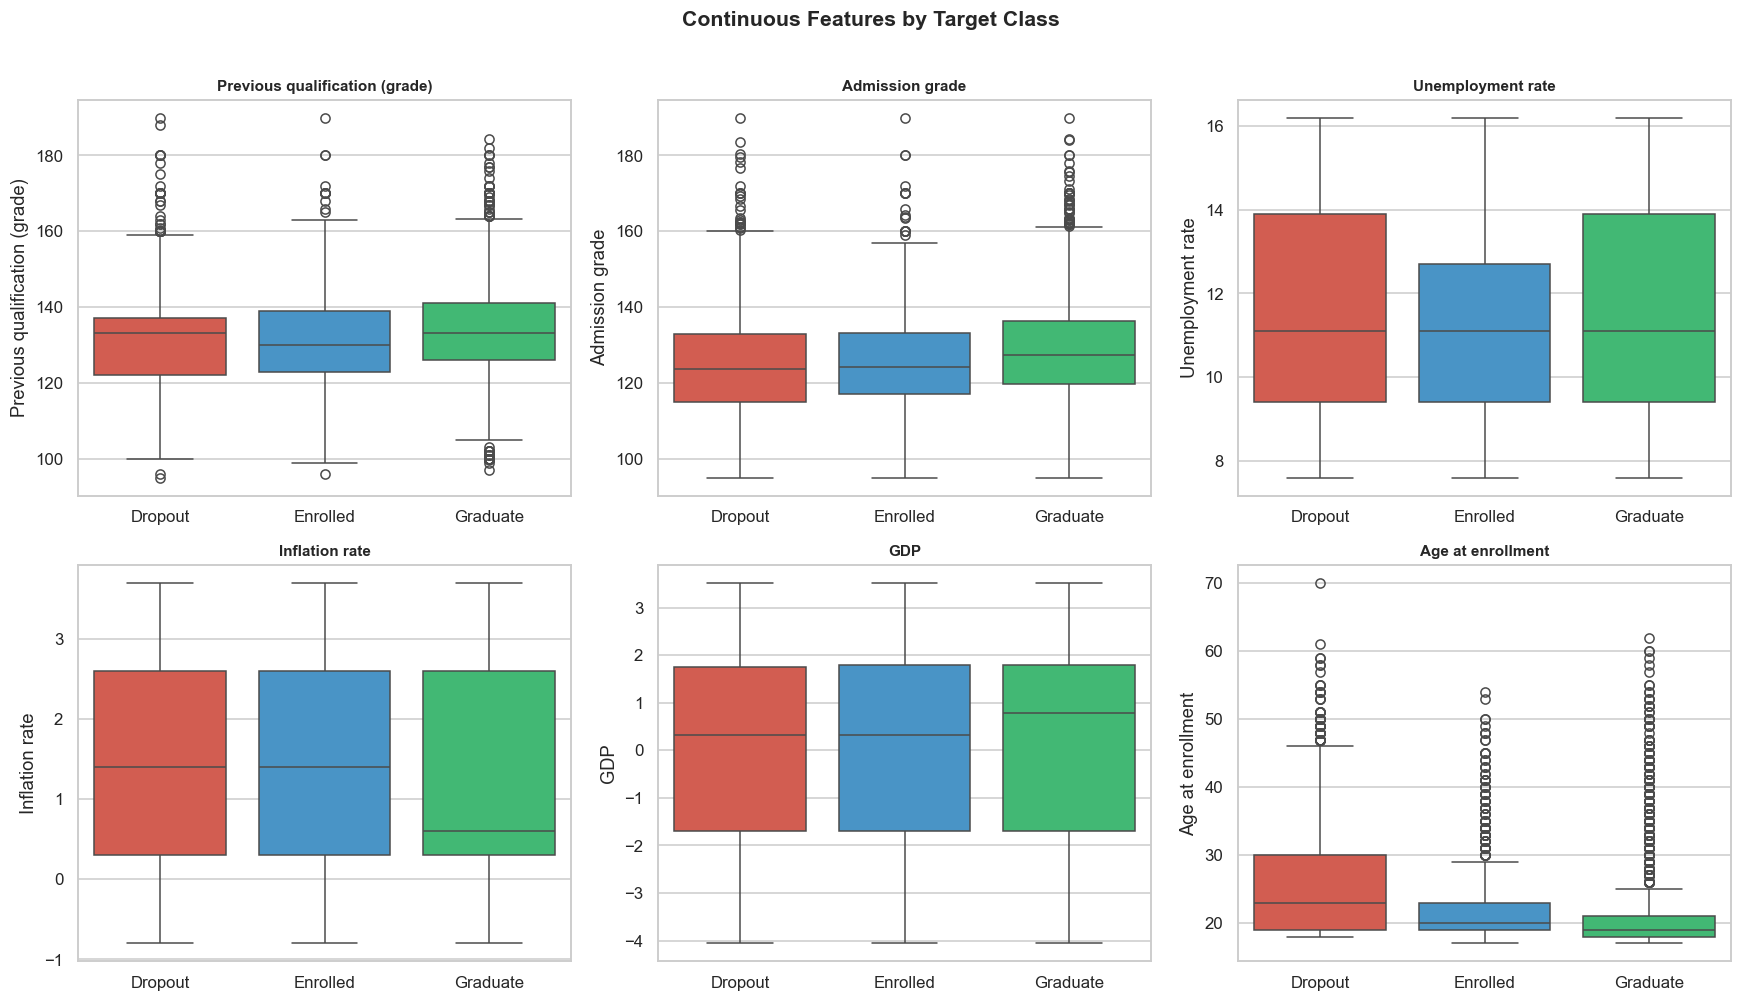

Figure saved.


In [9]:
df_box = df_num_preview.copy()
df_box['Target'] = df_raw['Target']

palette = {'Dropout': '#e74c3c', 'Enrolled': '#3498db', 'Graduate': '#2ecc71'}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df_box, x='Target', y=col, palette=palette, ax=axes[i],
                order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Continuous Features by Target Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots_by_target.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.7:** Graduate students tend to have higher admission grades and prior qualification grades compared to dropouts. Age at enrollment is similar across all three groups, though dropouts skew slightly older — possibly reflecting mature students who face more competing pressures.


### 2.8 Curricular Unit Performance

The EDA strongly suggests that curricular unit performance (units approved and grades) will be the most important predictors. Let's look at this more closely.


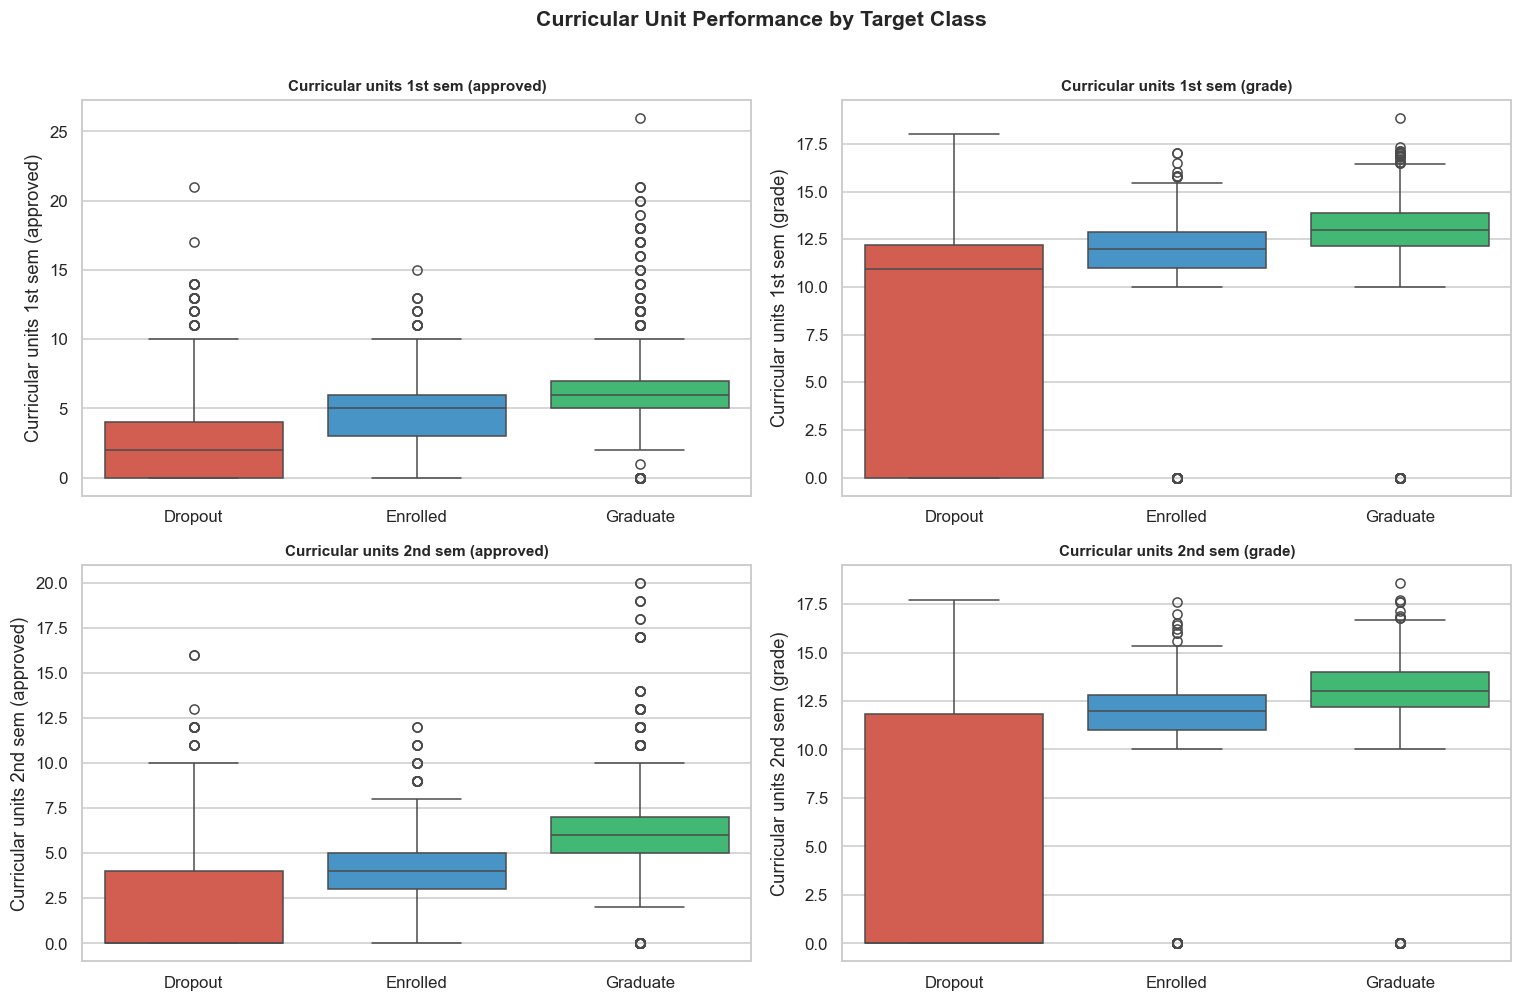

Figure saved.


In [10]:
cu_cols = [
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cu_cols):
    sns.boxplot(data=df_box, x='Target', y=col, palette=palette, ax=axes[i],
                order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Curricular Unit Performance by Target Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_curricular_units.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.8:** This is the clearest signal in the whole dataset. Dropout students cluster near zero for both approved units and grades in both semesters — they essentially stop engaging academically early on. Graduate students consistently approve a high number of units with strong grades. Enrolled students fall somewhere in between. These features will almost certainly dominate the model's feature importance rankings.


### 2.9 Categorical Feature Analysis

Let's see how some of the binary/categorical features vary across the three outcome classes.


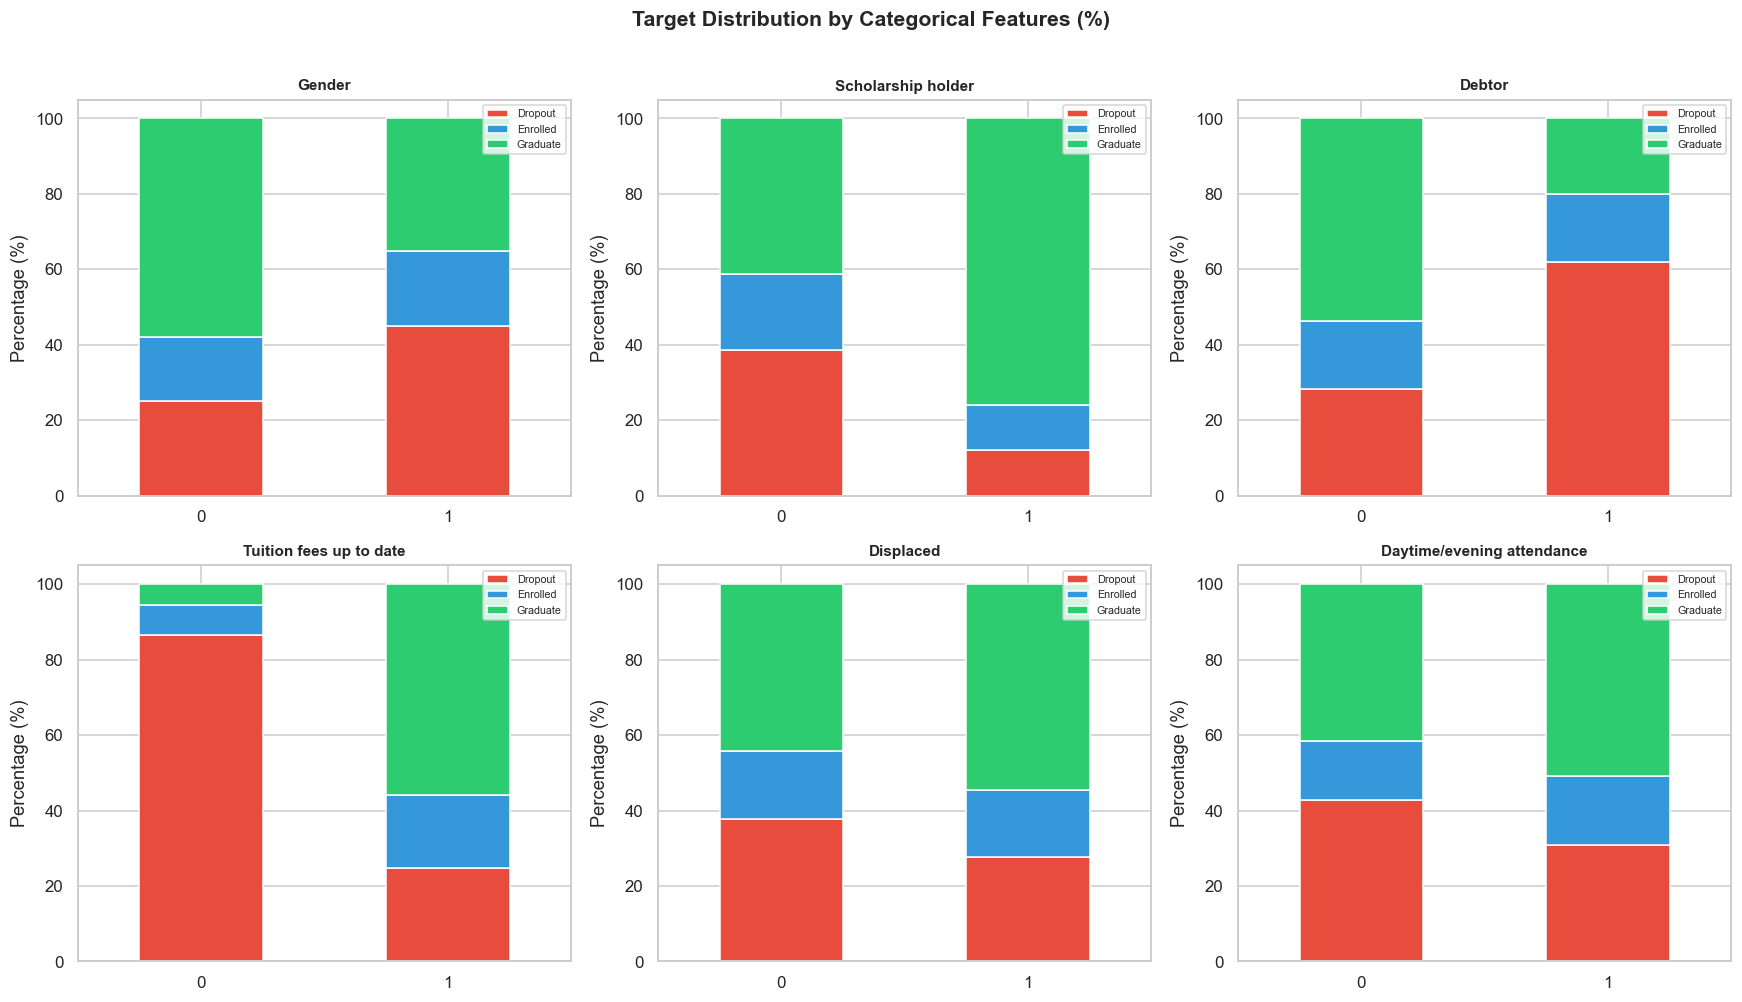

Figure saved.


In [11]:
cat_cols = ['Gender', 'Scholarship holder', 'Debtor',
            'Tuition fees up to date', 'Displaced', 'Daytime/evening attendance']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    col_series = pd.to_numeric(df_raw[col], errors='coerce')
    temp_df = pd.DataFrame({'col': col_series, 'Target': df_raw['Target']}).dropna()
    temp_df['col'] = temp_df['col'].astype(int)
    ct = pd.crosstab(temp_df['col'], temp_df['Target'], normalize='index') * 100
    for cls in ['Dropout', 'Enrolled', 'Graduate']:
        if cls not in ct.columns:
            ct[cls] = 0
    ct[['Dropout', 'Enrolled', 'Graduate']].plot(
        kind='bar', stacked=True, ax=axes[i],
        color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white'
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(loc='upper right', fontsize=7)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Target Distribution by Categorical Features (%)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_categorical_features.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.9:** Financial features tell a clear story:

- **Tuition fees up to date**: Students who are current with their fees are far more likely to graduate. Students in arrears drop out at a much higher rate — this is one of the strongest predictors in the dataset.
- **Debtor**: Being a debtor is strongly linked to dropout. Financial stress is clearly a major driver of non-completion.
- **Scholarship holder**: Scholarship students graduate at a higher rate and drop out less — financial support acts as a protective factor.
- **Gender**: Male students have a slightly higher dropout rate than female students.
- **Evening attendance**: Evening students drop out more often, probably because many are working adults juggling competing demands.


### 2.10 Correlation Analysis

Let's check for multicollinearity and see which features are most correlated with the target.


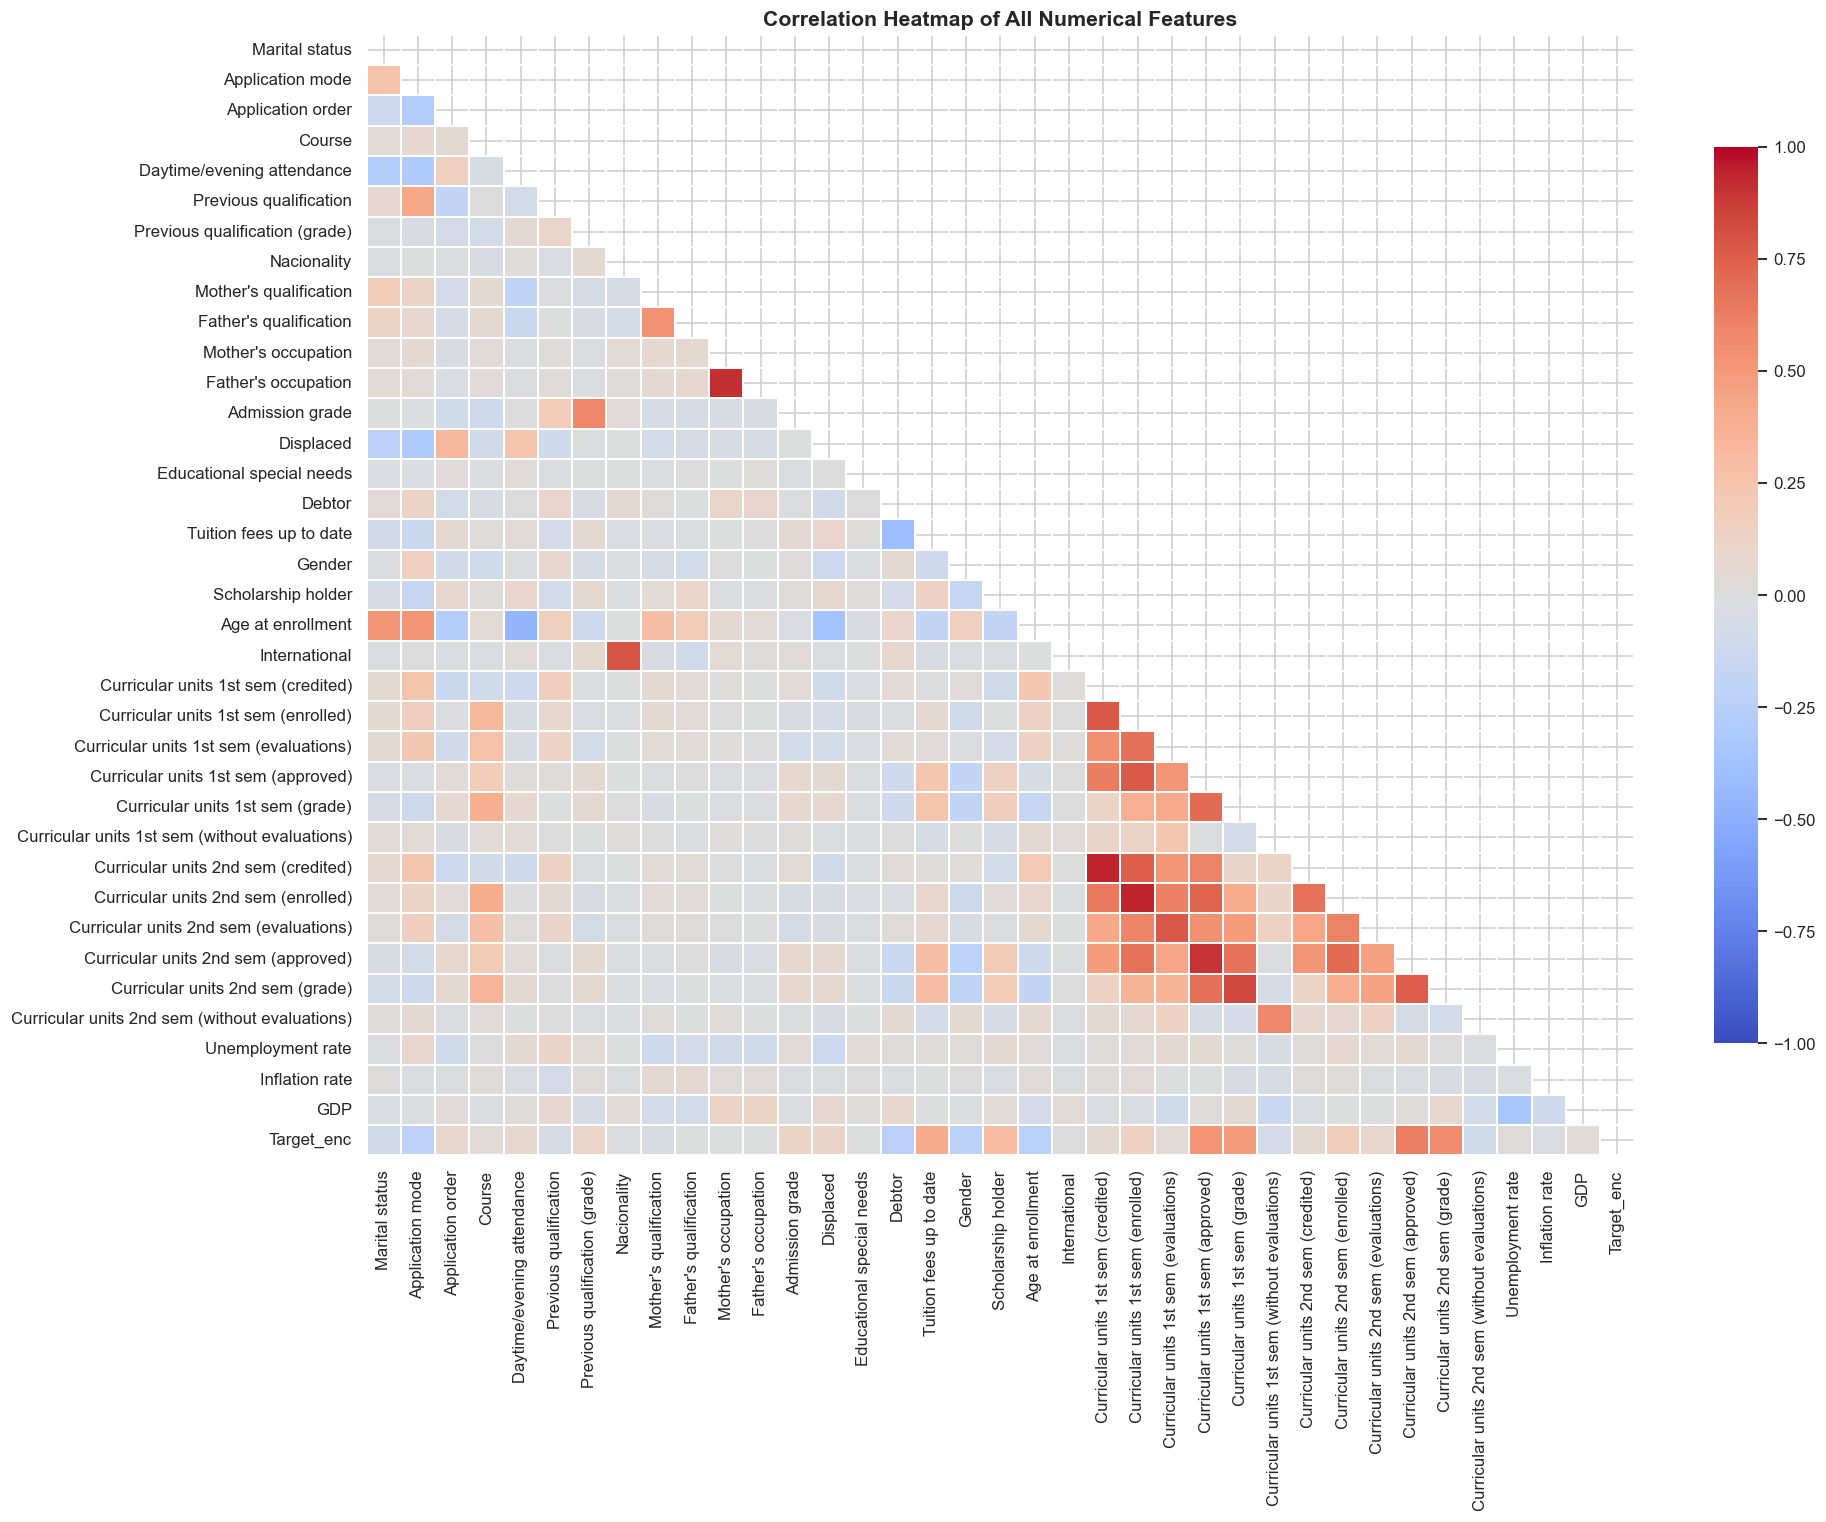

Figure saved.


In [12]:
df_corr = df_num_preview.copy()
le_temp = LabelEncoder()
df_corr['Target_enc'] = le_temp.fit_transform(df_raw['Target'])
df_corr_num = df_corr.select_dtypes(include=[np.number])
corr_matrix = df_corr_num.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, ax=ax, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of All Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


In [13]:
target_corr = corr_matrix['Target_enc'].drop('Target_enc').sort_values(key=abs, ascending=False)
print("Top 15 features correlated with Target (encoded):")
print(target_corr.head(15).round(3).to_string())


Top 15 features correlated with Target (encoded):
Curricular units 2nd sem (approved)    0.624
Curricular units 2nd sem (grade)       0.567
Curricular units 1st sem (approved)    0.529
Curricular units 1st sem (grade)       0.485
Tuition fees up to date                0.410
Scholarship holder                     0.298
Age at enrollment                     -0.243
Debtor                                -0.241
Gender                                -0.229
Application mode                      -0.222
Curricular units 2nd sem (enrolled)    0.176
Curricular units 1st sem (enrolled)    0.156
Admission grade                        0.121
Displaced                              0.114
Previous qualification (grade)         0.104


**EDA Finding 2.10:** The curricular unit features (approved units and grades) have the strongest correlations with the target — no surprises there. `Tuition fees up to date` and `Scholarship holder` also show notable correlations. The macroeconomic variables (GDP, unemployment, inflation) have very low correlations, confirming they won't add much predictive power at the individual level.

Worth noting: the 1st and 2nd semester curricular unit features are highly correlated with each other (students who do well in semester 1 tend to do well in semester 2). This multicollinearity is fine for tree-based models but worth keeping in mind for Logistic Regression.

### 2.11 Outlier Detection


In [14]:
outlier_summary = {}
for col in continuous_cols:
    series = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    outlier_summary[col] = {
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2),
        'Outlier Count': n_out,
        'Outlier (%)': round(n_out / len(series) * 100, 2)
    }

pd.DataFrame(outlier_summary).T


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
Previous qualification (grade),125.0,140.00,15.00,102.50,162.50,179.0,4.05
Admission grade,117.9,134.80,16.90,92.55,160.15,86.0,1.94
Unemployment rate,9.4,13.90,4.50,2.65,20.65,0.0,0.00
Inflation rate,0.3,2.60,2.30,-3.15,6.05,0.0,0.00
GDP,-1.7,1.79,3.49,-6.94,7.02,0.0,0.00
Age at enrollment,19.0,25.00,6.00,10.00,34.00,441.0,9.97


**EDA Finding 2.11:** `Age at enrollment` has the highest proportion of outliers — these are mature students and are genuine data points, not errors. We'll keep them. Tree-based models handle outliers just fine; Logistic Regression will benefit from the feature scaling we'll apply in the data preparation phase.


### 2.12 Summary of EDA Findings

| Finding | What it means for modelling |
|---|---|
| Dirty data: `'?'`, `'UnKnown'`, `'Na'`, `NaN` in multiple columns | Needs cleaning before modelling |
| Moderate class imbalance (Graduate > Dropout > Enrolled) | Use stratified split; consider `class_weight='balanced'` |
| Curricular unit features are highly discriminative | These will dominate feature importance |
| Tuition fees, debtor status, and scholarship are strong predictors | Keep all financial features |
| Age at enrollment is right-skewed with outliers | Apply scaling for linear models |
| Macroeconomic features show low correlation with target | May contribute little predictive power |
| Multicollinearity between 1st and 2nd semester features | Monitor in Logistic Regression |